## Introduction 

In this script, the global closeness per ward is computed. 

## Reading in the Python libraries

In [1]:
from pathlib import Path

import geopandas as gpd
import momepy
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

## Loading the data

In [9]:
BASE_DIR = Path.cwd().parent
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_chennai" / "chennai_graphml.graphml"

# WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [3]:
## Detailed wards
df_inpath = PROCESSED_DIR / "chennai_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\chennai_fix_mapshaper.shp


In [4]:
df = gpd.read_file(df_inpath)
df.head()

,Name,zone_id,zone_name,geometry
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584..."
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ..."
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ..."
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13...."
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318..."


In [5]:
print(f'There are {df.shape[0]} wards in the dataset.')

There are 200 wards in the dataset.


Reading in the entire Bangalore network data that we had downloaded earlier as again we will "truncate" the network to the different street networks at the ward level:

In [10]:
G = ox.io.load_graphml(path_graphml)

In [11]:
G.graph["crs"]

'epsg:4326'

In [12]:
df.crs.to_epsg()

4326

## Computing (global) closeness at the ward level

In [18]:
results = pd.DataFrame(columns=['Name', 'zone_id', 'zone_name', 'closeness'])
results

,Name,zone_id,zone_name,closeness


In [19]:
## for ward in tqdm(range(0,5), desc="Processing wards"):
for ward in tqdm(range(0,len(df)), desc = "Processing wards"):

    ## print(f'Processing the {ward} ward.')

    Name = df['Name'].iloc[ward]
    zone_id = df['zone_id'].iloc[ward]
    zone_name = df['zone_name'].iloc[ward]
    
    ## print(name_ward)

    df_ward = df.iloc[[ward]]

    ## ward_geometry = df.iloc[ward,:].geometry
    ward_geometry = df_ward.geometry.iloc[0]

    ## https://docs.momepy.org/en/stable/user_guide/simple/shape.html#Street-network-shapes
    G_clipped = ox.truncate.truncate_graph_polygon(G, ward_geometry)

    streets_graph = ox.projection.project_graph(G_clipped)

    edges = ox.graph_to_gdfs(
    ox.convert.to_undirected(streets_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
    )

    primal = momepy.gdf_to_nx(edges, approach="primal")

    primal = momepy.closeness_centrality(primal, name='closeness_global', weight='mm_len')

    nodes = momepy.nx_to_gdf(primal, lines=False)

    closeness_mean = nodes['closeness_global'].mean()

    results.loc[ward] = [
        Name,
        zone_id,
        zone_name,
        closeness_mean
    ]
    

Processing wards: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [17:58<00:00,  5.39s/it]


In [20]:
results

,Name,zone_id,zone_name,closeness
0,168,13,Adyar,0.000671
1,169,13,Adyar,0.000464
2,170,13,Adyar,0.000558
3,171,13,Adyar,0.000818
4,174,13,Adyar,0.000814
...,...,...,...,...
195,110,9,Teynampet,0.000764
196,161,12,Alandur,0.000762
197,160,12,Alandur,0.001597
198,195,15,Sholinganallur,0.000625


In [21]:
top10_highest = (
    results
    .sort_values(by='closeness', ascending=False)
    .head(10)
)
top10_highest

,Name,zone_id,zone_name,closeness
166,13,1,Thiruvottyur,0.002159
95,77,6,Thiru-Vi-Ka. Nagar,0.002015
129,51,5,Royapuram,0.001981
121,56,5,Royapuram,0.001873
148,48,4,Tondiarpet,0.001853
119,54,5,Royapuram,0.001793
165,12,1,Thiruvottyur,0.001672
182,140,10,Kodambakkam,0.001667
83,164,12,Alandur,0.001643
175,33,3,Madhavaram,0.001635


In [22]:
top10_lowest = (
    results
    .sort_values(by='closeness', ascending=True)
    .head(10)
)
top10_lowest

,Name,zone_id,zone_name,closeness
63,18,2,Manali,0.000314
17,200,15,Sholinganallur,0.000359
162,7,1,Thiruvottyur,0.000370
8,172,13,Adyar,0.000374
19,197,15,Sholinganallur,0.000418
71,83,7,Ambattur,0.000419
62,17,2,Manali,0.000433
107,150,11,Valasaravakkam,0.000442
1,169,13,Adyar,0.000464
74,86,7,Ambattur,0.000472


In [23]:
print(f'The mean of the global closeness across the wards is {results["closeness"].mean()}.')
print(f'The minimum of the global closeness across the wards is {results["closeness"].min()}.')
print(f'The maximum of the global closeness across the wards is {results["closeness"].max()}.')

The mean of the global closeness across the wards is 0.0009828761649915733.
The minimum of the global closeness across the wards is 0.0003135900245473566.
The maximum of the global closeness across the wards is 0.0021594696282682267.


In [27]:
## Save this:
results_path = PROCESSED_DIR / "results_chennai_global_closeness_all_roads.csv"

results.to_csv(results_path)

In [29]:
# You can normally do things from results but I had to read them in later
results_path = PROCESSED_DIR / "results_chennai_global_closeness_all_roads.csv"
results = pd.read_csv(results_path)

In [30]:
results = pd.read_csv(results_path)
results

,Unnamed: 0,Name,zone_id,zone_name,closeness
0,0,168,13,Adyar,0.000671
1,1,169,13,Adyar,0.000464
2,2,170,13,Adyar,0.000558
3,3,171,13,Adyar,0.000818
4,4,174,13,Adyar,0.000814
...,...,...,...,...,...
195,195,110,9,Teynampet,0.000764
196,196,161,12,Alandur,0.000762
197,197,160,12,Alandur,0.001597
198,198,195,15,Sholinganallur,0.000625


In [31]:
df_merged = df.merge(results, on = 'Name')
df_merged

,Name,zone_id_x,zone_name_x,geometry,Unnamed: 0,zone_id_y,zone_name_y,closeness
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",0,13,Adyar,0.000671
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",1,13,Adyar,0.000464
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",2,13,Adyar,0.000558
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",3,13,Adyar,0.000818
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",4,13,Adyar,0.000814
...,...,...,...,...,...,...,...,...
195,110,9,Teynampet,"POLYGON ((80.23114 13.05407, 80.23115 13.05415...",195,9,Teynampet,0.000764
196,161,12,Alandur,"POLYGON ((80.20783 13.00072, 80.20781 13.00064...",196,12,Alandur,0.000762
197,160,12,Alandur,"MULTIPOLYGON (((80.20702 12.99931, 80.20702 12...",197,12,Alandur,0.001597
198,195,15,Sholinganallur,"POLYGON ((80.24569 12.93725, 80.24554 12.93576...",198,15,Sholinganallur,0.000625


In [32]:
df_merged = df_merged[['Name', 'zone_id_x', 'zone_name_x', 'geometry', 'closeness']]
df_merged

,Name,zone_id_x,zone_name_x,geometry,closeness
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",0.000671
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",0.000464
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",0.000558
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",0.000818
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",0.000814
...,...,...,...,...,...
195,110,9,Teynampet,"POLYGON ((80.23114 13.05407, 80.23115 13.05415...",0.000764
196,161,12,Alandur,"POLYGON ((80.20783 13.00072, 80.20781 13.00064...",0.000762
197,160,12,Alandur,"MULTIPOLYGON (((80.20702 12.99931, 80.20702 12...",0.001597
198,195,15,Sholinganallur,"POLYGON ((80.24569 12.93725, 80.24554 12.93576...",0.000625


In [33]:
# Rename the columns
df_merged = df_merged.rename(columns={
    'zone_id_x': 'zone_id',
    'zone_name_x': 'zone_name'
})

## Plots

The ward with the highest straightness

In [34]:
# Find the index label of the row with the maximum value in column 'C'
mask = df_merged['closeness'] == df_merged['closeness'].max()

# Apply the mask to the DataFrame
max_rows_df = df_merged[mask]

print(max_rows_df)

     Name  zone_id     zone_name  \
166    13        1  Thiruvottyur   

                                              geometry  closeness  
166  POLYGON ((80.2901 13.14461, 80.2898 13.14476, ...   0.002159  


In [36]:
print(f'The ward with the highest closeness is {max_rows_df["Name"]}')


The ward with the highest closeness is 166    13
Name: Name, dtype: int32


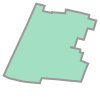

In [37]:
geom_highest = max_rows_df.geometry.iloc[0]
geom_highest

In [40]:
# Find the index label of the row with the maximum value in column 'C'
mask = df_merged['closeness'] == df_merged['closeness'].min()

# Apply the mask to the DataFrame
min_rows_df = df_merged[mask]

print(min_rows_df)

    Name  zone_id zone_name  \
63    18        2    Manali   

                                             geometry  closeness  
63  POLYGON ((80.25483 13.19168, 80.25775 13.19175...   0.000314  


In [41]:
print(f'The ward with the lowest straightness is {min_rows_df["Name"]}')

The ward with the lowest straightness is 63    18
Name: Name, dtype: int32


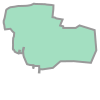

In [42]:
geom_lowest = min_rows_df.geometry.iloc[0]
geom_lowest

In [46]:
G_clipped_lowest = ox.truncate.truncate_graph_polygon(G, geom_lowest)

In [41]:
# path_gpkg_bang_truncated = PROCESSED_DIR / "gpkg_chennai" / "test_truncated.gpkg"
# ox.io.save_graph_geopackage(G_clipped_lowest, filepath=path_gpkg_bang_truncated)

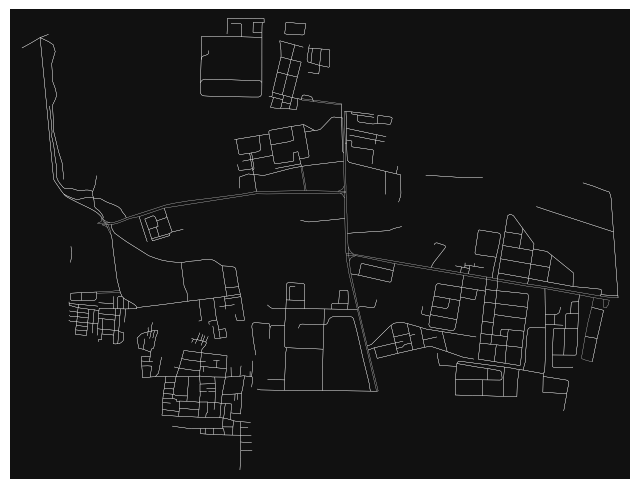

In [47]:
fig, ax = ox.plot_graph(G_clipped_lowest, node_size=0, edge_color="w", edge_linewidth=0.2)

Plot the closeness at the wards:

In [48]:
## Path to save the figure:
fig_path = IMAGES_DIR / 'closeness_global_all_roads_chennai.png'

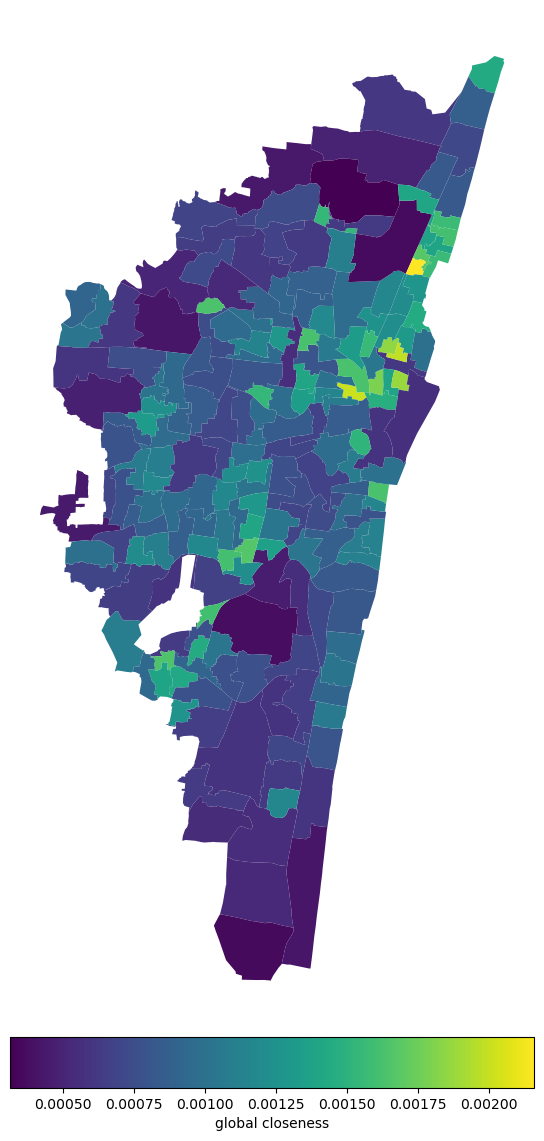

In [49]:
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 1, figsize=(14, 14))

divider = make_axes_locatable(ax)

cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_merged.plot(
    column="closeness",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={"label": "global closeness", "orientation": "horizontal"},
)
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()